# Identification of Van-der-Pol oscillator system

In [439]:
# import all the necessary libraries
import pysindy as ps
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

We consider the following Van-der-Pol oscillator
$$\ddot{x}-\mu (1-x^2) \dot{x} + x = 0$$

In [440]:
# The van der pol oscillator system
def van_der_pol(t, x, mu=0.5):
    return [x[1], 
           mu * (1-x[0] ** 2) * x[1] - x[0]]

In [441]:
# generate the data for testing
start = 0
end = 30
step = 0.01
t_span = [start, end]
x0 = [0.3, 0.1]
sol = solve_ivp(van_der_pol, t_span, x0, dense_output=True)
t = np.arange(start, end+step/10, step)
x = sol.sol(t).T

In [442]:
# The feature names of the columns of y
feature_names = ['x1', 'x2']

# Which feature library to use
# Here I'm using a polynomial library that contains all combinations of the columns upto the degree 3
feature_library = ps.PolynomialLibrary(degree=3)

# Differentiation method
differentiation_method = ps.FiniteDifference(order=2)


# Optimizer
opt = ps.SR3(threshold=0.1)

# Building the model
model=ps.SINDy(differentiation_method=differentiation_method,
               feature_library = feature_library,
               feature_names=feature_names, 
              optimizer=opt)

# Fitting the model to the training data
model.fit(x,t=t)

# Print the model
model.print()

(x1)' = 1.000 x2
(x2)' = -1.002 x1 + 0.502 x2 + -0.500 x1^2 x2


The correct answer is
$$\begin{aligned}
& \dot{x}_1=x_2 \\
& \dot{x}_2=-x_1+\mu x_2-\mu x_1^2 x_2
\end{aligned}$$

In [443]:
# Simulate the identified system 
sim = model.simulate(x0,t=t)

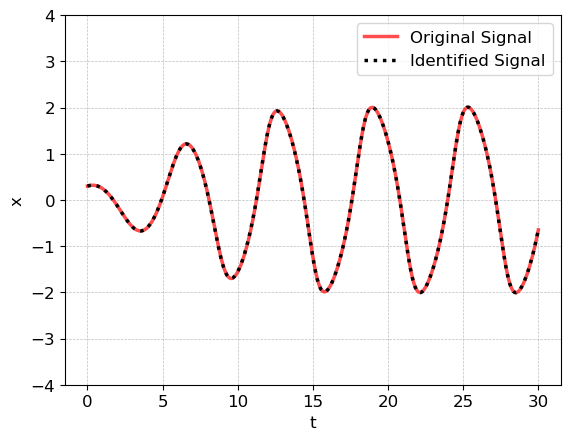

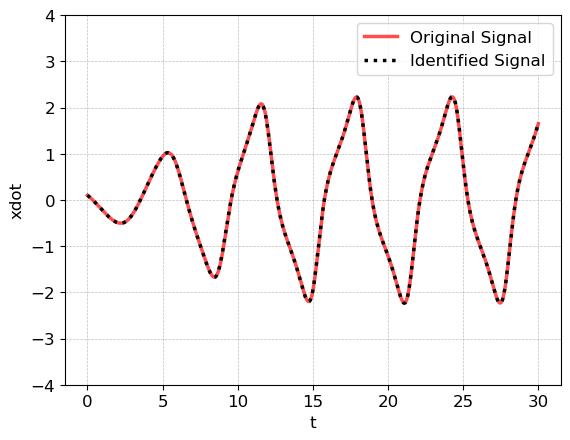

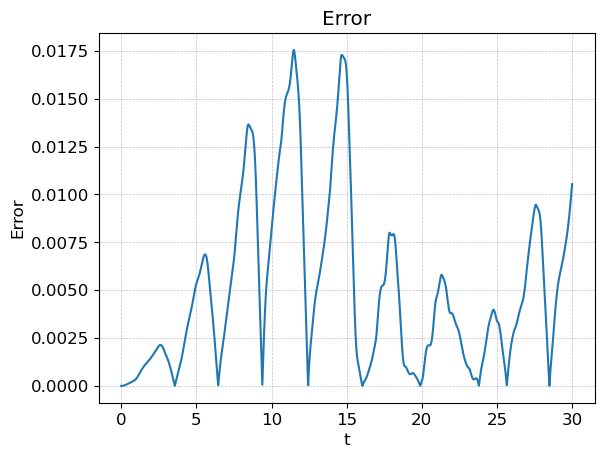

In [444]:
# plot the solution

plt.rcParams.update({'font.size': 12})

# displacement
plt.plot(t,x[:,0],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,0],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("x")
plt.ylim((-4,4))
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('disp_vdp.pdf', format='pdf', dpi=300)
plt.show()

# velocity
plt.plot(t,x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(t,sim[:,1],'k:',linewidth=2.5,label="Identified Signal")
plt.xlabel("t")
plt.ylabel("xdot")
plt.ylim((-4,4))
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('vel_vdp.pdf', format='pdf', dpi=300)
plt.show()

# Error
plt.plot(t, np.abs(sim[:,0]-x[:,0]))
plt.title("Error")
plt.xlabel("t")
plt.ylabel("Error")
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('error_vdp.pdf', format='pdf', dpi=300)
plt.show()

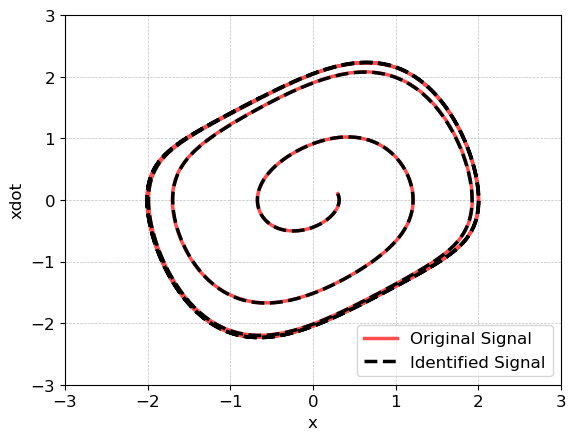

In [445]:
# velocity
plt.plot(x[:,0],x[:,1],'r',alpha=0.7,linewidth=2.5, label="Original Signal")
plt.plot(sim[:,0],sim[:,1],'k--',linewidth=2.5,label="Identified Signal")
plt.xlabel("x")
plt.ylabel("xdot")
plt.legend(loc='lower right')
plt.xlim((-3,3))
plt.ylim((-3,3))
plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
plt.savefig('pp_vdp.pdf', format='pdf', dpi=300)
plt.show()